In [1]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)


In [3]:
# =====================================================
# LOAD DATASET
# =====================================================

file_path = "../data/processed/energy_clean.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:")
print(df.shape)

df.head()


Dataset Shape:
(2075259, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Timestamp
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,16/12/2006 17:24:00
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,16/12/2006 17:25:00
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,16/12/2006 17:26:00
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,16/12/2006 17:27:00
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,16/12/2006 17:28:00


In [4]:
# =====================================================
# DATA INSPECTION
# =====================================================

print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 10 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
 9   Timestamp              str    
dtypes: float64(7), str(3)
memory usage: 158.3 MB
None

Missing Values:
Date                         0
Time                         0
Global_active_power      25903
Global_reactive_power    25903
Voltage                  25903
Global_intensity         25903
Sub_metering_1           25903
Sub_metering_2           25903
Sub_metering_3           25903
Timestamp                    0
dtype: int64

Duplicate Rows:
0


In [5]:
df.isnull().sum()
print(df.head())
print(df.info())
print(df.shape)
print(df.columns)
df.duplicated().sum()

         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
0              18.4             0.0             1.0            17.0   
1              23.0             0.0             1.0            16.0   
2              23.0             0.0             2.0            17.0   
3              23.0             0.0             1.0            17.0   
4              15.8             0.0             1.0            17.0   

             Timestamp  
0  16/12/2006 17:24:00  
1  16/12/2006 17:25:00  
2  16/12/2006 17:

np.int64(0)

In [6]:
# =====================================================
# DATETIME CONVERSION
# =====================================================

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

df.set_index("Timestamp", inplace=True)

df.head()


C:\Users\new user account\AppData\Local\Temp\ipykernel_14344\1918768003.py:5: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Timestamp"] = pd.to_datetime(df["Timestamp"])


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Timestamp,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
# =====================================================
# FEATURE ENGINEERING
# =====================================================

df["Hour"] = df.index.hour

df["Day"] = df.index.day_name()

df["Month"] = df.index.month_name()

df["Weekend"] = np.where(df.index.dayofweek >= 5,
"Weekend",
"Weekday")

df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour,Day,Month,Weekend
Timestamp,,,,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,17,Saturday,December,Weekend
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,17,Saturday,December,Weekend
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,17,Saturday,December,Weekend
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,17,Saturday,December,Weekend
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,17,Saturday,December,Weekend


In [8]:
# =====================================================
# DESCRIPTIVE STATISTICS
# =====================================================

summary_stats = df.describe()

summary_stats


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
count,2.049356e+06,2.049356e+06,2.049356e+06,2.049356e+06,2.049356e+06,2.049356e+06,2.049356e+06,2.075259e+06
mean,1.091645e+00,1.237169e-01,2.408398e+02,4.627889e+00,1.121981e+00,1.298590e+00,6.458515e+00,1.150076e+01
std,1.057324e+00,1.127237e-01,3.239989e+00,4.444523e+00,6.153206e+00,5.822073e+00,8.437165e+00,6.922227e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.200000e+01
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,1.800000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2.300000e+01


In [9]:
# =====================================================
# ADDITIONAL STATISTICS
# =====================================================

stats = df[
[
"Global_active_power",
"Global_reactive_power",
"Voltage",
"Global_intensity"
]
].agg(
[
"mean",
"median",
"std",
"min",
"max"
]
)

stats


,Global_active_power,Global_reactive_power,Voltage,Global_intensity
mean,1.091645,0.123717,240.839792,4.627889
median,0.602000,0.100000,241.010000,2.600000
std,1.057324,0.112724,3.239989,4.444523
min,0.076000,0.000000,223.200000,0.200000
max,11.122000,1.390000,254.150000,48.400000


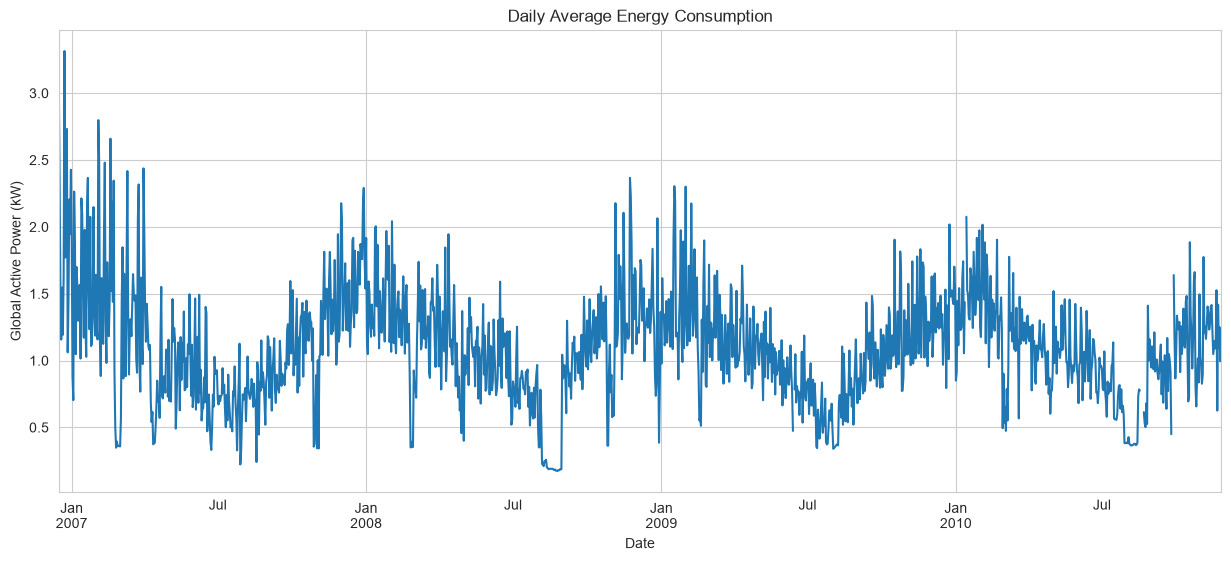

In [10]:
# =====================================================
# DAILY TREND
# =====================================================

daily_trend = df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(15,6))
daily_trend.plot()

plt.title("Daily Average Energy Consumption")
plt.ylabel("Global Active Power (kW)")
plt.xlabel("Date")

plt.savefig(
"../reports/figures/daily_trend.png",
bbox_inches="tight"
)

plt.show()


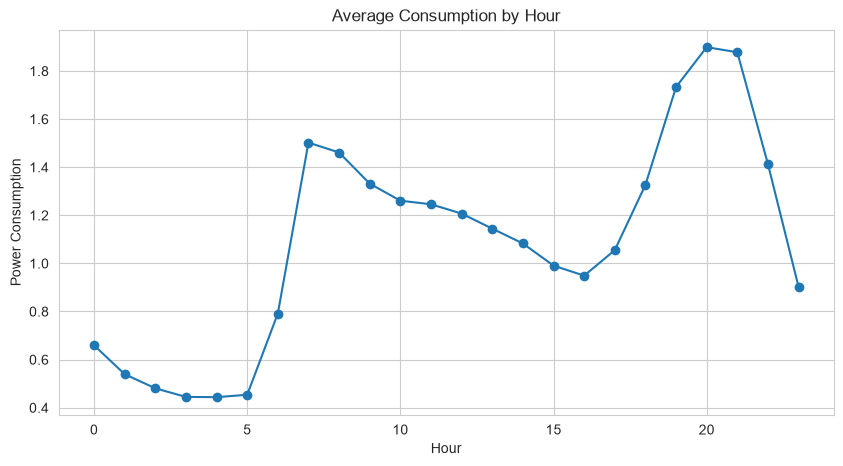

In [11]:
# =====================================================
# HOURLY PATTERN
# =====================================================

hourly_pattern = df.groupby(
"Hour"
)["Global_active_power"].mean()

plt.figure(figsize=(10,5))

hourly_pattern.plot(
marker='o'
)

plt.title("Average Consumption by Hour")

plt.ylabel("Power Consumption")

plt.savefig(
"../reports/figures/hourly_pattern.png",
bbox_inches="tight"
)

plt.show()


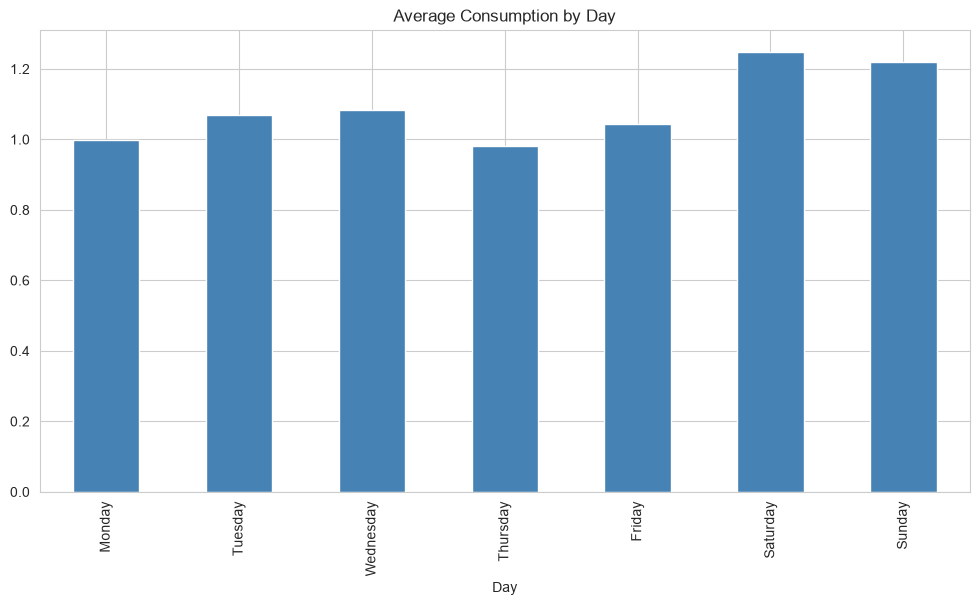

In [12]:
# =====================================================
# DAILY PATTERN
# =====================================================

day_order = [
"Monday",
"Tuesday",
"Wednesday",
"Thursday",
"Friday",
"Saturday",
"Sunday"
]

daily_pattern = (
df.groupby("Day")
["Global_active_power"]
.mean()
.reindex(day_order)
)

daily_pattern.plot(
kind="bar",
color="steelblue"
)

plt.title("Average Consumption by Day")

plt.savefig(
"../reports/figures/daily_pattern.png",
bbox_inches="tight"
)

plt.show()


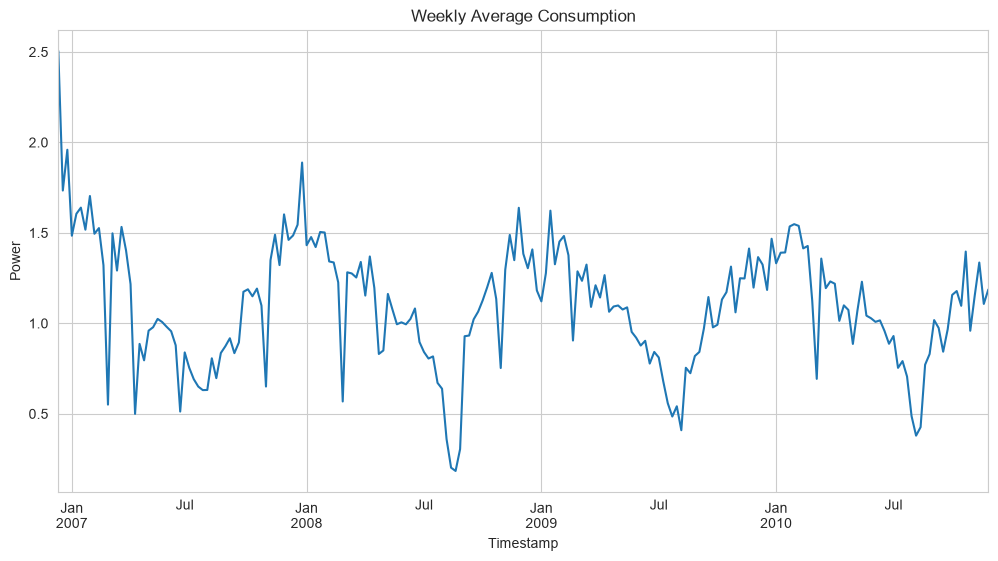

In [13]:
# =====================================================
# WEEKLY TREND
# =====================================================

weekly_pattern = (
df["Global_active_power"]
.resample("W")
.mean()
)

weekly_pattern.plot()

plt.title("Weekly Average Consumption")

plt.ylabel("Power")

plt.savefig(
"../reports/figures/weekly_pattern.png",
bbox_inches="tight"
)

plt.show()


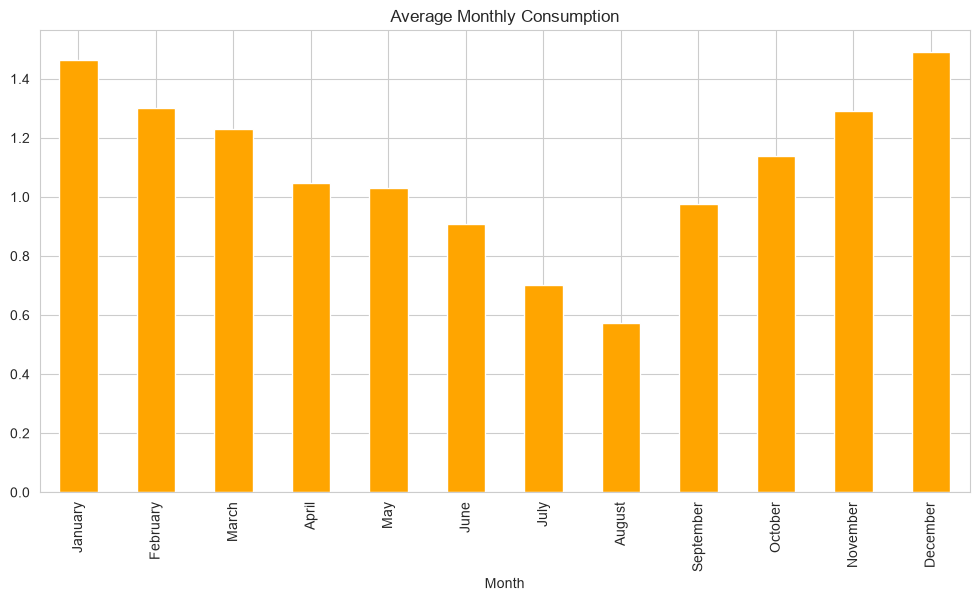

In [14]:
# =====================================================
# MONTHLY PATTERN
# =====================================================

month_order = [
'January','February','March',
'April','May','June',
'July','August','September',
'October','November','December'
]

monthly_pattern = (
df.groupby("Month")
["Global_active_power"]
.mean()
.reindex(month_order)
)

monthly_pattern.plot(
kind="bar",
color="orange"
)

plt.title("Average Monthly Consumption")

plt.savefig(
"../reports/figures/monthly_pattern.png",
bbox_inches="tight"
)

plt.show()


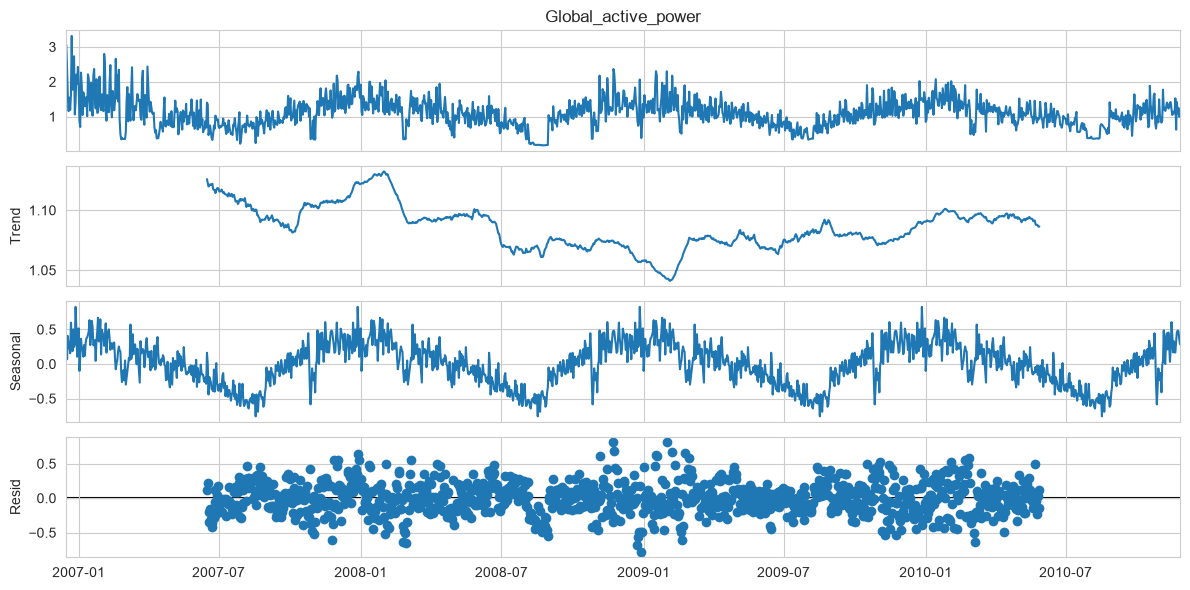

In [ ]:
# SEOSONAL DECOMPOSITION

daily_data = (
    df["Global_active_power"]
    .resample("D")
    .mean()
)

# Fill missing days
daily_data = daily_data.interpolate(method="time")

from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    daily_data,
    model="additive",
    period=365
)

decomposition.plot()
plt.show()

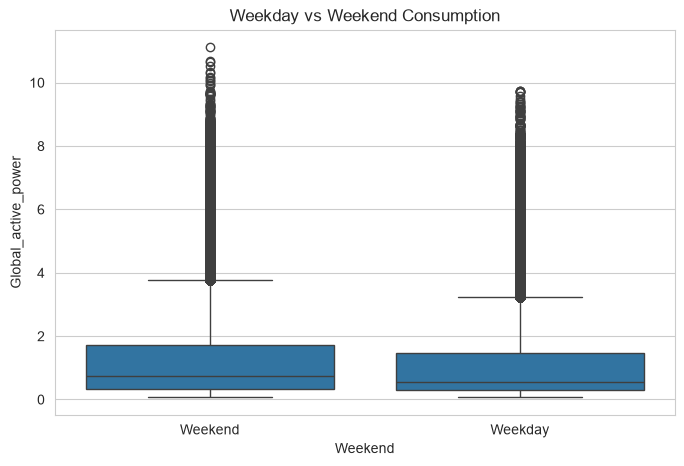

In [17]:
# =====================================================
# WEEKDAY VS WEEKEND
# =====================================================

plt.figure(figsize=(8,5))

sns.boxplot(
x="Weekend",
y="Global_active_power",
data=df
)

plt.title("Weekday vs Weekend Consumption")

plt.savefig(
"../reports/figures/weekday_vs_weekend.png",
bbox_inches="tight"
)

plt.show()


In [18]:
# =====================================================
# PEAK DEMAND HOURS
# =====================================================

peak_hours = (
hourly_pattern
.sort_values(ascending=False)
.head(5)
)

low_hours = (
hourly_pattern
.sort_values()
.head(5)
)

print("Top 5 Peak Hours")
print(peak_hours)

print("\nTop 5 Lowest Hours")
print(low_hours)


Top 5 Peak Hours
Hour
20    1.899103
21    1.877786
19    1.733347
7     1.502264
8     1.461049
Name: Global_active_power, dtype: float64

Top 5 Lowest Hours
Hour
4    0.443847
3    0.444866
5    0.453674
2    0.480618
1    0.539325
Name: Global_active_power, dtype: float64


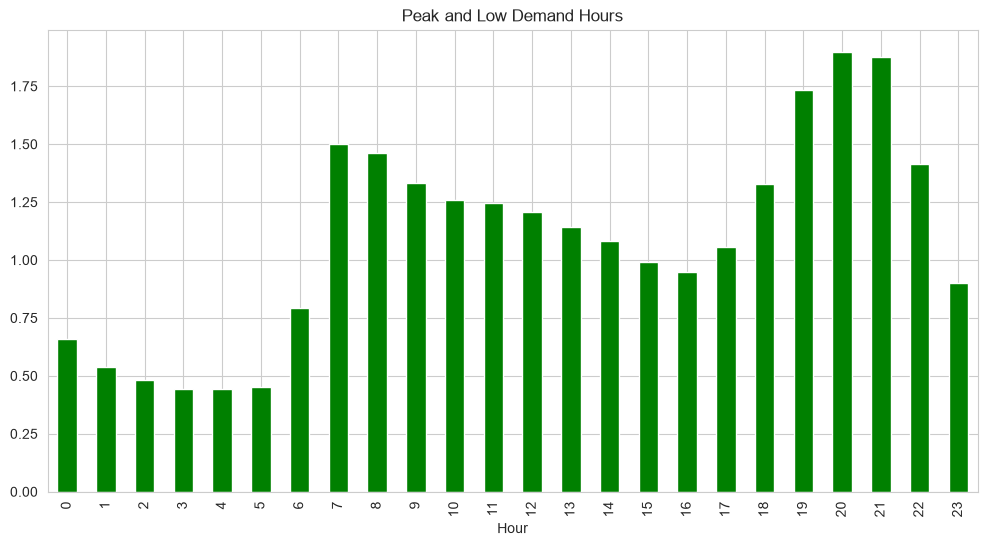

In [19]:
hourly_pattern.plot(
kind="bar",
color="green"
)

plt.title("Peak and Low Demand Hours")

plt.savefig(
"../reports/figures/demand_periods.png",
bbox_inches="tight"
)

plt.show()


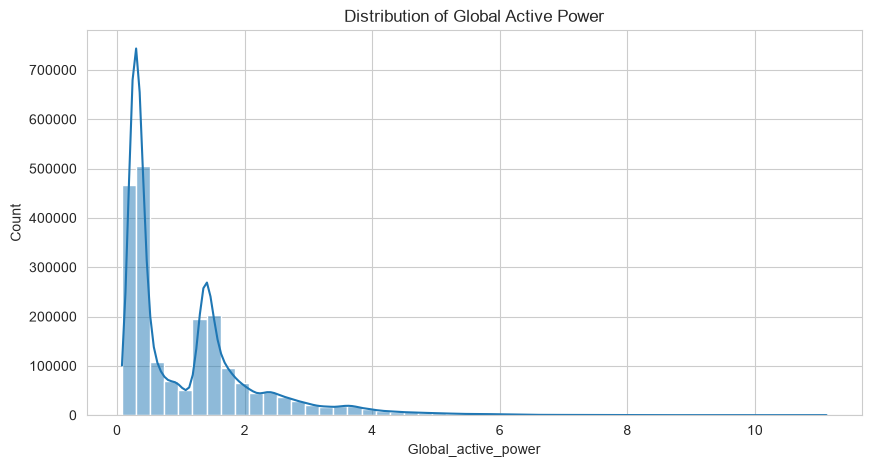

In [20]:
# =====================================================
# DISTRIBUTION
# =====================================================

plt.figure(figsize=(10,5))

sns.histplot(
df["Global_active_power"],
bins=50,
kde=True
)

plt.title("Distribution of Global Active Power")

plt.savefig(
"../reports/figures/consumption_distribution.png",
bbox_inches="tight"
)

plt.show()


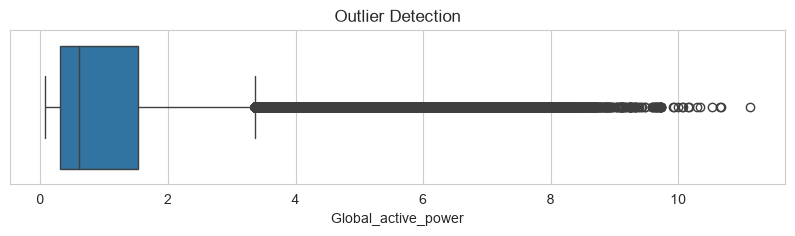

In [21]:
plt.figure(figsize=(10,2))

sns.boxplot(
x=df["Global_active_power"]
)

plt.title("Outlier Detection")

plt.show()


In [22]:
# =====================================================
# CORRELATION MATRIX
# =====================================================

corr_matrix = df.corr(
numeric_only=True
)

corr_matrix


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Hour
Global_active_power,1.000000,0.247036,-0.399767,0.998889,0.484409,0.434578,0.638552,0.281606
Global_reactive_power,0.247036,1.000000,-0.112253,0.266138,0.123123,0.139246,0.089615,0.127901
Voltage,-0.399767,-0.112253,1.000000,-0.411369,-0.195970,-0.167409,-0.268178,-0.176054
Global_intensity,0.998889,0.266138,-0.411369,1.000000,0.489305,0.440356,0.626539,0.281976
Sub_metering_1,0.484409,0.123123,-0.195970,0.489305,1.000000,0.054735,0.102578,0.108484
Sub_metering_2,0.434578,0.139246,-0.167409,0.440356,0.054735,1.000000,0.080874,0.087214
Sub_metering_3,0.638552,0.089615,-0.268178,0.626539,0.102578,0.080874,1.000000,0.113869
Hour,0.281606,0.127901,-0.176054,0.281976,0.108484,0.087214,0.113869,1.000000


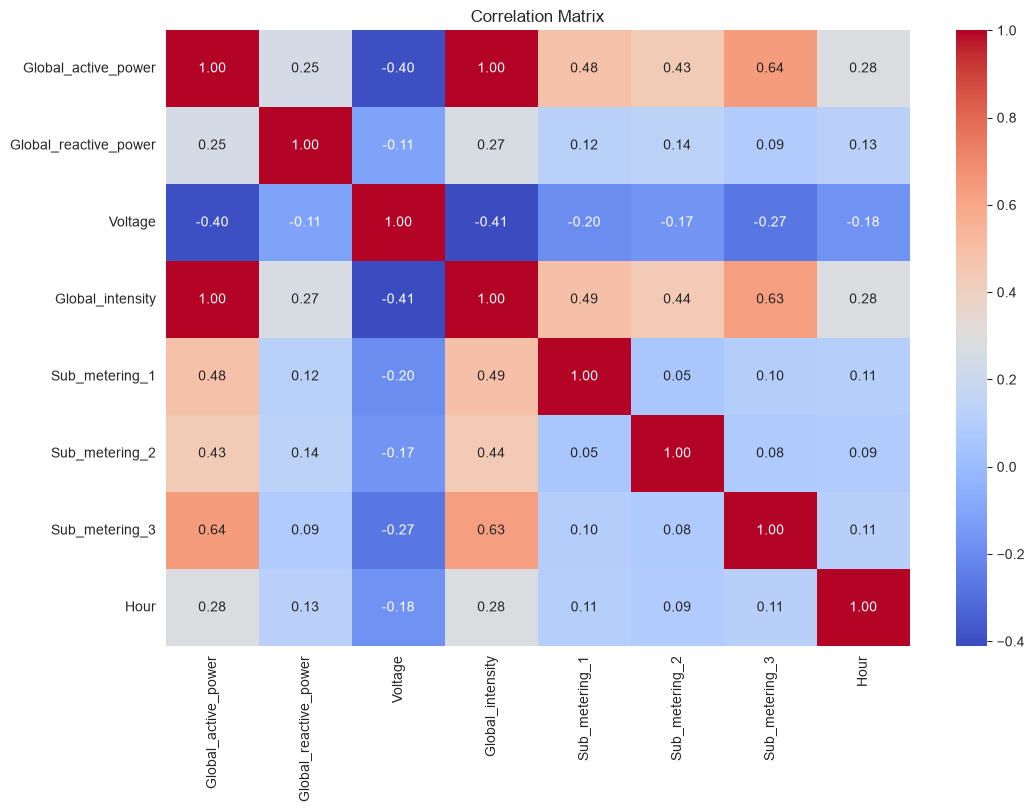

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
corr_matrix,
annot=True,
cmap="coolwarm",
fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig(
"../reports/figures/correlation_heatmap.png",
bbox_inches="tight"
)

plt.show()


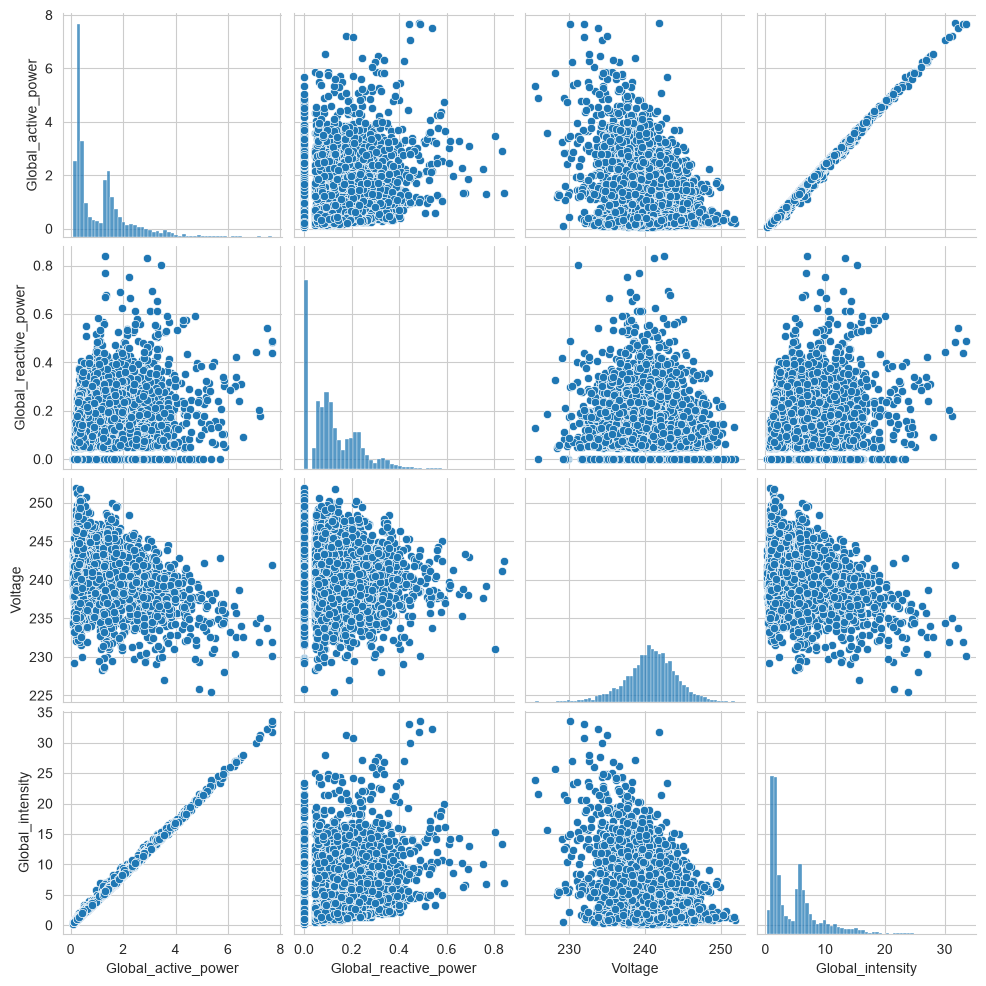

In [24]:
# =====================================================
# PAIRPLOT
# =====================================================

sample_df = df[
[
"Global_active_power",
"Global_reactive_power",
"Voltage",
"Global_intensity"
]
].sample(5000)

sns.pairplot(sample_df)

plt.show()


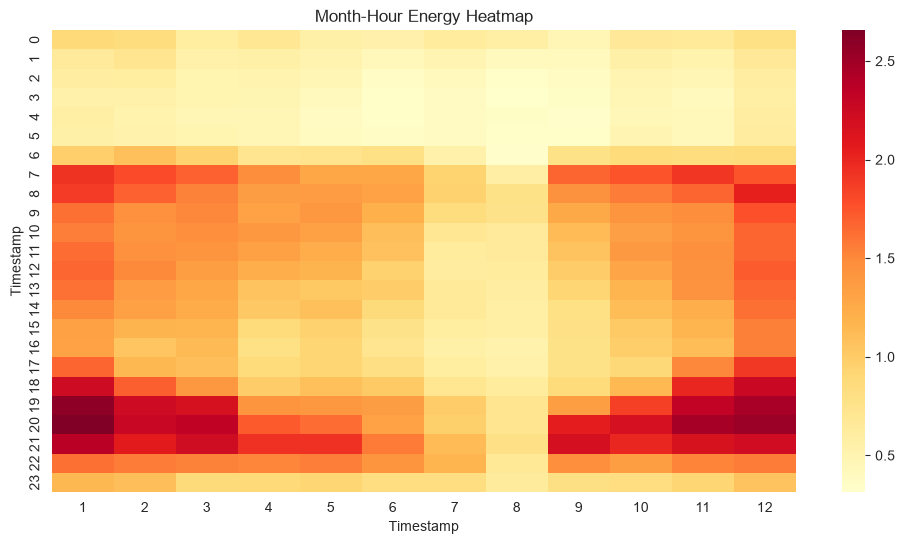

In [25]:
# =====================================================
# MONTH-HOUR HEATMAP
# =====================================================

heatmap_data = pd.pivot_table(
df,
values="Global_active_power",
index=df.index.hour,
columns=df.index.month,
aggfunc="mean"
)

plt.figure(figsize=(12,6))

sns.heatmap(
heatmap_data,
cmap="YlOrRd"
)

plt.title("Month-Hour Energy Heatmap")

plt.savefig(
"../reports/figures/monthly_hour_heatmap.png",
bbox_inches="tight"
)

plt.show()


In [26]:
# =====================================================
# EDA SUMMARY
# =====================================================

print("====== EDA SUMMARY ======")

print(
f"Average Active Power: "
f"{df['Global_active_power'].mean():.2f}"
)

print(
f"Maximum Active Power: "
f"{df['Global_active_power'].max():.2f}"
)

print(
f"Minimum Active Power: "
f"{df['Global_active_power'].min():.2f}"
)

print(
"\nPeak Consumption Hour:"
)

print(
hourly_pattern.idxmax()
)

print(
"\nLowest Consumption Hour:"
)

print(
hourly_pattern.idxmin()
)


====== EDA SUMMARY ======
Average Active Power: 1.09
Maximum Active Power: 11.12
Minimum Active Power: 0.08

Peak Consumption Hour:
20

Lowest Consumption Hour:
4
